# Classifying Iris Dataset Using SVM Algorithm

In [59]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns

In [60]:
# loading the Iris Datset
iris = datasets.load_iris()

In [61]:
# Selecting Specific features
X = iris.data[:,[2,3]]
y = iris.target

In [62]:
X

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

In [63]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [64]:
print("Feature Names:", iris.feature_names)
print("Target Names :",iris.target_names)

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names : ['setosa' 'versicolor' 'virginica']


In [65]:
# View of Some sample of iris datset
print("Sample of Datset: ")
for i in range(5):
    print(f"Sample  {i+1}: {X[i]} (Class: {y[i]},Species : {iris.target_names[y[i]]})")

Sample of Datset: 
Sample  1: [1.4 0.2] (Class: 0,Species : setosa)
Sample  2: [1.4 0.2] (Class: 0,Species : setosa)
Sample  3: [1.3 0.2] (Class: 0,Species : setosa)
Sample  4: [1.5 0.2] (Class: 0,Species : setosa)
Sample  5: [1.4 0.2] (Class: 0,Species : setosa)


In [66]:
# Creating DataFrame
iris_df = pd.DataFrame(X, columns=iris.feature_names[2:])
iris_df['target'] = y

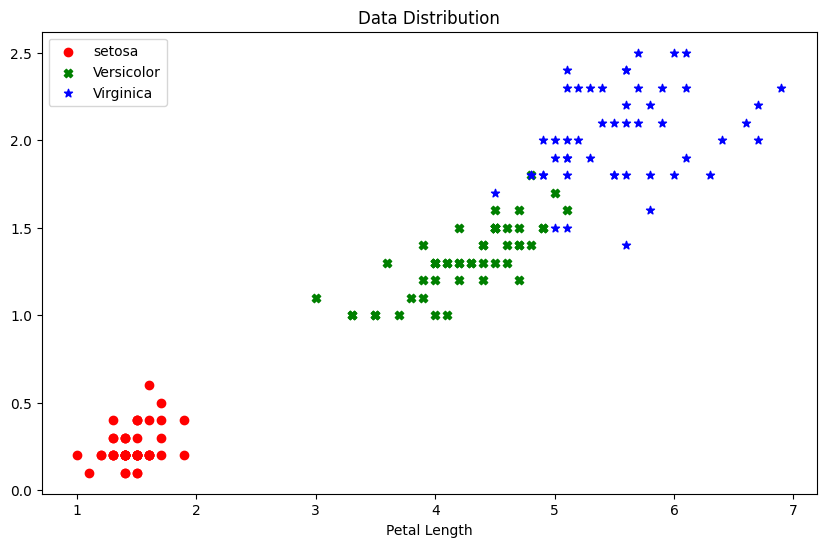

In [67]:
plt.figure(figsize=(10,6))
plt.scatter(X[y ==0,0],X[y ==0 , 1], color='red', marker='o',label ='setosa')
plt.scatter(X[y ==1,0],X[y ==1 , 1], color='green', marker='X',label ='Versicolor')
plt.scatter(X[y ==2,0],X[y ==2 , 1], color='blue', marker='*',label ='Virginica')

plt.xlabel('Petal Length')
plt.legend(loc = 'upper left')
plt.title('Data Distribution')
plt.show()

In [68]:
# Train Test Split
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.3,random_state=42)

In [69]:
# StandardScaler
sc = StandardScaler()
X_train_sd = sc.fit_transform(X_train)
X_test_sd = sc.fit_transform(X_test)

In [70]:
svm = SVC(kernel='linear',C= 1, random_state=0)
svm.fit(X_train_sd,y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
# defines a function called plot_decision_regions that can be used to visualize decision boundaries of a classifier.
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # Setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Plot all samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=cmap(idx),
                    marker=markers[idx], label=cl)

plt.show()
    

In [72]:
X_combined_std = np.vstack((X_train_sd, X_test_sd))
y_combined = np.hstack((y_train,y_test))

C:\Users\kawsa\AppData\Local\Temp\ipykernel_8468\3898532754.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


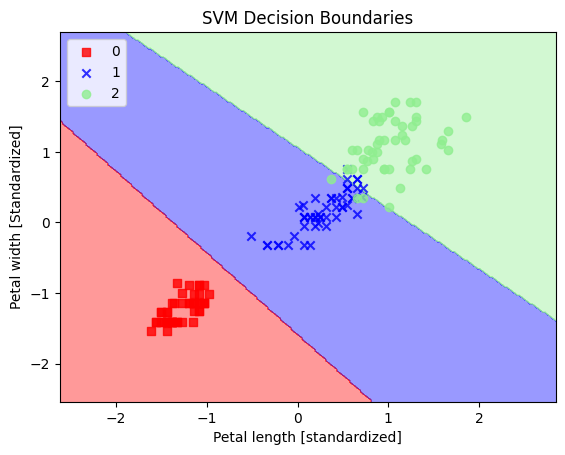

In [73]:
plot_decision_regions(X_combined_std,y_combined,classifier=svm)
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [Standardized]')
plt.legend(loc = 'upper left')
plt.title('SVM Decision Boundaries')
plt.show()

In [74]:
# Make prediction
y_pred = svm.predict(X_test_sd)
cm = confusion_matrix

In [75]:
print("Confusion Matrix : \n",cm)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : ", accuracy)

Confusion Matrix : 
 <function confusion_matrix at 0x0000021582F636A0>
Accuracy :  0.9555555555555556


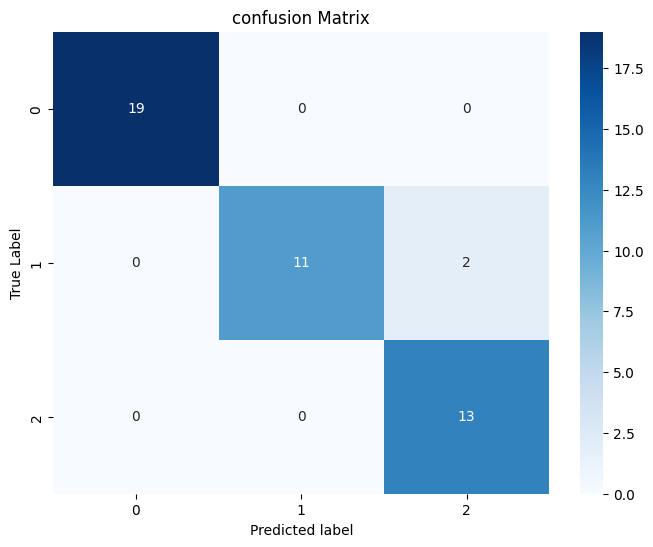

In [76]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True Label')
plt.title('confusion Matrix')
plt.show()